# Tier 8 · Notebook 40 — CLIP & Multimodal Contrastive Learning

> **Goal:** connect **images and text in a shared embedding space** so a model can match pictures to descriptions — and do **zero-shot classification** from class *names* alone. We build a mini **CLIP** (Radford et al. 2021) from scratch: two encoders, the **contrastive (InfoNCE) loss**, and the shared space that makes text-to-image and multimodal LLMs possible.

**The idea.** Train an **image encoder** and a **text encoder** so that a matching (image, caption) pair lands at *nearby* points in a shared embedding space, and non-matching pairs land *far apart*. Do this over hundreds of millions of web (image, caption) pairs and you get a model that "understands" images through language — with a superpower: **zero-shot classification.** To classify an image into arbitrary categories, you don't retrain — you just embed the category *names* as text ("a photo of a cat", "a photo of a dog"), embed the image, and pick the nearest text. No labeled training set for the new task at all. This is the model behind DALL·E's text understanding, and the vision half of multimodal LLMs.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
tr = datasets.MNIST("../data", train=True, download=True, transform=tf)
te = datasets.MNIST("../data", train=False, download=True, transform=tf)
words = ["zero","one","two","three","four","five","six","seven","eight","nine"]
print("we treat MNIST digit images as 'images' and their number-words as 'captions':", words[:4], "...")


we treat MNIST digit images as 'images' and their number-words as 'captions': ['zero', 'one', 'two', 'three'] ...


## 0. The contrastive objective (InfoNCE)

Take a batch of $N$ (image, text) pairs. Encode all images to vectors $I_1..I_N$ and all texts to $T_1..T_N$, then L2-normalize (so dot product = cosine similarity). Form the $N\times N$ **similarity matrix** $S_{ij} = I_i\cdot T_j / \tau$ (temperature $\tau$). The **contrastive loss** says: for each image, its *matching* text should be the most similar among all texts in the batch — i.e., the **diagonal** of $S$ should win. That's just a **cross-entropy** where the correct "class" for image $i$ is text $i$:
$$\mathcal{L} = \tfrac12\big[\text{CE}(S, \text{diag}) + \text{CE}(S^{\mathsf T}, \text{diag})\big]$$
(symmetric — image→text and text→image). This is **InfoNCE**: pull matching pairs together, push the $N-1$ mismatches apart. The other pairs in the batch serve as **negatives** — bigger batches = more negatives = a stronger signal.


In [2]:
class ImageEncoder(nn.Module):
    def __init__(s, d=64):
        super().__init__(); s.conv=nn.Sequential(nn.Conv2d(1,16,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
                                                 nn.Conv2d(16,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        s.proj=nn.Linear(32*7*7, d)
    def forward(s,x): return s.proj(s.conv(x).flatten(1))

class TextEncoder(nn.Module):                       # encodes the 10 caption-words
    def __init__(s, d=64): super().__init__(); s.emb=nn.Embedding(10,32); s.proj=nn.Sequential(nn.Linear(32,64),nn.ReLU(),nn.Linear(64,d))
    def forward(s, ids): return s.proj(s.emb(ids))

img_enc, txt_enc = ImageEncoder().to(device), TextEncoder().to(device)
temperature = nn.Parameter(torch.tensor(0.07))      # learned temperature (as in CLIP)
opt = torch.optim.Adam(list(img_enc.parameters())+list(txt_enc.parameters())+[temperature], 1e-3)

Xtr = tr.data.float().reshape(-1,1,28,28); Xtr=(Xtr/255-0.1307)/0.3081; ytr=tr.targets
def contrastive_step(bs=256):
    ix = torch.randint(0, len(Xtr), (bs,))
    imgs = Xtr[ix].to(device); caption_ids = ytr[ix].to(device)      # each image's caption = its digit-word
    I = F.normalize(img_enc(imgs), dim=1)                            # L2-normalized image embeddings
    T = F.normalize(txt_enc(caption_ids), dim=1)                     # L2-normalized text embeddings
    logits = I @ T.T / temperature.clamp(0.01, 1.0)                  # (bs, bs) similarity matrix
    labels = torch.arange(bs, device=device)                        # matching pair = the diagonal
    loss = 0.5*(F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))
    return loss

for step in range(2000):
    loss = contrastive_step(); opt.zero_grad(); loss.backward(); opt.step()
    if step%500==0 or step==1999: print(f"step {step:4d}  contrastive loss {loss.item():.3f}")


step    0  contrastive loss 6.587


step  500  contrastive loss 3.340


step 1000  contrastive loss 3.328


step 1500  contrastive loss 3.291


step 1999  contrastive loss 3.315


## 1. The similarity matrix should become diagonal

After training, a batch's image–text similarity matrix should light up on the **diagonal** (each image most similar to its own caption) and be dark off-diagonal (dissimilar to others). This is the contrastive objective, visualized.


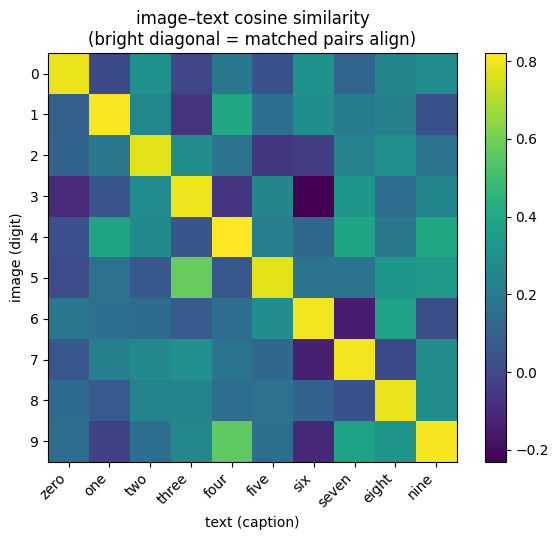

diagonal dominance: 1.0 of images most-similar to their own caption


In [3]:
# one example per digit -> a clean 10x10 image-vs-text similarity matrix
ex_imgs = torch.stack([Xtr[(ytr==c).nonzero()[0,0]] for c in range(10)]).to(device)
with torch.no_grad():
    I = F.normalize(img_enc(ex_imgs), dim=1)
    T = F.normalize(txt_enc(torch.arange(10, device=device)), dim=1)
    S = (I @ T.T).cpu().numpy()
fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(S, cmap="viridis")
ax.set_xticks(range(10)); ax.set_xticklabels(words, rotation=45, ha="right"); ax.set_yticks(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel("text (caption)"); ax.set_ylabel("image (digit)"); ax.set_title("image–text cosine similarity\n(bright diagonal = matched pairs align)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print("diagonal dominance:", (S.argmax(1)==np.arange(10)).mean(), "of images most-similar to their own caption")
assert (S.argmax(1) == np.arange(10)).mean() >= 0.9, (
    f"only {(S.argmax(1)==np.arange(10)).mean():.2f} of digits align with their own caption - "
    f"contrastive training did not align the two modalities")


## 2. Zero-shot classification — from class names alone

The payoff: to classify a **test** image, we don't use a trained classifier head. We embed the **10 caption-words** as text, embed the image, and pick the **nearest text embedding** — classification purely by *matching to language*. This is exactly how CLIP does open-vocabulary zero-shot recognition.


In [4]:
Xte = (te.data.float().reshape(-1,1,28,28)/255-0.1307)/0.3081
yte = te.targets
with torch.no_grad():
    T = F.normalize(txt_enc(torch.arange(10, device=device)), dim=1)      # embed the class NAMES
    correct = 0
    for i in range(0, 10000, 1000):
        I = F.normalize(img_enc(Xte[i:i+1000].to(device)), dim=1)
        pred = (I @ T.T).argmax(1).cpu()                                  # nearest caption = predicted class
        correct += (pred == yte[i:i+1000]).sum().item()
print(f"zero-shot classification via nearest text embedding: {correct/10000:.4f} accuracy")
print("(no classifier head trained — images matched directly to the class-name embeddings)")
assert correct / 10000 > 0.9, \
    f"zero-shot accuracy {correct/10000:.4f} - matching images to class-name embeddings failed"


zero-shot classification via nearest text embedding: 0.9901 accuracy
(no classifier head trained — images matched directly to the class-name embeddings)


**What to notice.** The similarity matrix is strongly **diagonal** — training aligned each image with its caption in the shared space — and we classify test images with high accuracy **by matching them to text embeddings of the class names**, with *no* classifier head. That's the CLIP mechanism: a shared image-text space turns classification into a *retrieval* problem against language.

**An honest scope note:** our toy captions are just the 10 digit-words, so this shows the *mechanism* but not CLIP's most magical property — **open-vocabulary zero-shot to concepts never seen in training** (e.g., classifying a photo as "a golden retriever puppy" without any dog training data). That emerges because real CLIP's **text encoder is a full language model** trained on web-scale (image, caption) pairs, so it places *arbitrary* phrases meaningfully in the space. Same objective and architecture — just a language-pretrained text encoder and 400M pairs instead of 10 words.


## 3. Visualize the shared embedding space

Project both image and text embeddings to 2-D. Matching images and text should **co-locate** by class — the geometric signature of a working multimodal space.


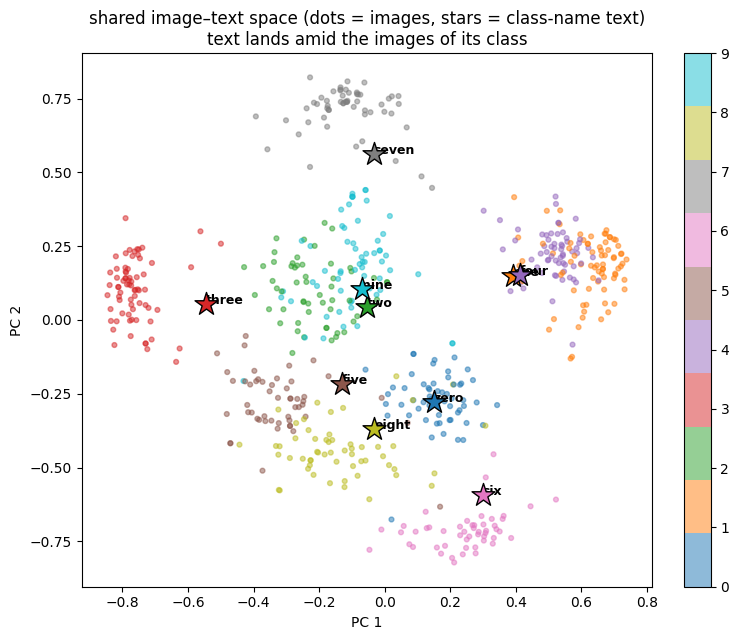

In [5]:
from numpy.linalg import svd
with torch.no_grad():
    idx = torch.randint(0, len(Xte), (600,))
    Iemb = F.normalize(img_enc(Xte[idx].to(device)), dim=1).cpu().numpy(); lab = yte[idx].numpy()
    Temb = F.normalize(txt_enc(torch.arange(10, device=device)), dim=1).cpu().numpy()
allv = np.vstack([Iemb, Temb]); allv = allv - allv.mean(0)
U,Sv,Vt = svd(allv, full_matrices=False); proj = allv @ Vt[:2].T          # PCA to 2-D
Ip, Tp = proj[:600], proj[600:]
fig, ax = plt.subplots(figsize=(7.5,6.5))
sc = ax.scatter(Ip[:,0], Ip[:,1], c=lab, cmap="tab10", s=12, alpha=0.5)
for c in range(10):
    ax.scatter(Tp[c,0], Tp[c,1], c=[plt.cm.tab10(c)], s=300, marker="*", edgecolor="k", zorder=5)
    ax.annotate(words[c], (Tp[c,0], Tp[c,1]), fontsize=9, fontweight="bold")
ax.set_title("shared image–text space (dots = images, stars = class-name text)\ntext lands amid the images of its class")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); plt.colorbar(sc, ticks=range(10), fraction=0.046)
plt.tight_layout(); plt.show()


**What to notice.** Each **text embedding** (star) sits right in the middle of its class's **image embeddings** (dots) — the two modalities occupy *one* space, aligned by meaning. That co-location is what makes cross-modal retrieval and zero-shot work: "closeness in the space" = "match in meaning," whether you're comparing image-to-image, text-to-text, or image-to-text.

## 4. What you built / learned
- The **contrastive / InfoNCE** objective: align matching image-text pairs, push mismatches apart (symmetric cross-entropy on the similarity matrix; batch negatives; temperature).
- Two encoders projecting into a **shared normalized embedding space**.
- **Zero-shot classification** by matching images to class-*name* text embeddings — no classifier head.
- Visualized the aligned shared space; and the honest limit (open-vocabulary zero-shot needs a language-pretrained text encoder + web-scale data).

## 5. Exercises
1. **Batch size & negatives.** Vary the batch size; more negatives should sharpen the space and improve zero-shot. Verify.
2. **Temperature.** Fix vs learn $\tau$; how does it affect the similarity distribution and training stability?
3. **Prompt engineering.** In real CLIP, "a photo of a {}" beats "{}" — why does the text template matter?
4. **Image-to-image retrieval.** Use the image encoder alone for nearest-neighbor retrieval; does it cluster by class?
5. **Held-out classes.** Train on digits 0–7, and test zero-shot on 8–9; why does it (mostly) fail here but work in real CLIP?
6. **Linear probe.** Freeze the image encoder and train a linear classifier on its features; compare to zero-shot.

## 6. Interview / residency framing
- *"What is CLIP / how does it work?"* → jointly train an image encoder and text encoder with a contrastive loss so matching (image, caption) pairs align in a shared embedding space; enables zero-shot via class-name matching.
- *"What's the contrastive (InfoNCE) loss?"* → symmetric cross-entropy on the image-text similarity matrix; the diagonal (matched pairs) should win; other pairs are negatives; temperature scales the logits.
- *"How does zero-shot classification work?"* → embed class *names* as text, embed the image, pick the nearest text — no task-specific training.
- *"Why do bigger batches help contrastive learning?"* → more in-batch negatives → a stronger contrastive signal.
- *"Where does CLIP's open-vocabulary power come from?"* → a language-model text encoder + web-scale (image, caption) pairs, so arbitrary phrases are placed meaningfully in the space.

## 📚 References & papers

This notebook reproduces / builds on:

- **Learning Transferable Visual Models From Natural Language Supervision (CLIP)** — Radford et al. (2021), arXiv:2103.00020. The reproduced method.
- **Representation Learning with Contrastive Predictive Coding (InfoNCE)** — Oord, Li & Vinyals (2018), arXiv:1807.03748. The contrastive loss.
- **A Simple Framework for Contrastive Learning (SimCLR)** — Chen et al. (2020), arXiv:2002.05709. Contrastive learning of visual representations.
- **Scaling Up Visual and Vision-Language Representation Learning (ALIGN)** — Jia et al. (2021), arXiv:2102.05918. Web-scale image-text contrastive.

---
**Next:** *Tier 8 · Notebook 41 — RAG & tool-use / agents*: retrieval-augmented generation and a tool-calling agent loop from scratch — how LLMs use external knowledge and take actions.
